# Milestone 2: Machine Learning Modeling

This notebook applies machine learning methods to predict high-value customers using early customer purchasing behavior.

The main goal is to build predictive models that classify whether a customer is likely to become high-value based on early transaction patterns.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [4]:
df = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2010-2011")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# Basic data cleaning
df = df.dropna(subset=["Customer ID", "Invoice", "Quantity", "Price", "InvoiceDate"])

# Keep only valid purchases
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

# Create total transaction value
df["TotalPrice"] = df["Quantity"] * df["Price"]

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [6]:
# Find each customer's first purchase date
first_purchase = df.groupby("Customer ID")["InvoiceDate"].min().reset_index()
first_purchase.columns = ["Customer ID", "FirstPurchaseDate"]

# Merge first purchase date back into the transaction-level dataset
df = df.merge(first_purchase, on="Customer ID", how="left")

# Calculate how many days after the first purchase each transaction happened
df["DaysSinceFirstPurchase"] = (df["InvoiceDate"] - df["FirstPurchaseDate"]).dt.days

df[["Customer ID", "InvoiceDate", "FirstPurchaseDate", "DaysSinceFirstPurchase"]].head()

,Customer ID,InvoiceDate,FirstPurchaseDate,DaysSinceFirstPurchase
0,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00,0
1,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00,0
2,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00,0
3,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00,0
4,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00,0


In [7]:
# Define early customer behavior window
early_window_days = 30

# Keep only transactions within the first 30 days after each customer's first purchase
early_df = df[df["DaysSinceFirstPurchase"] <= early_window_days]

early_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,FirstPurchaseDate,DaysSinceFirstPurchase
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01 08:26:00,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01 08:26:00,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00,0


In [8]:
# Aggregate early behavior at customer level
early_features = early_df.groupby("Customer ID").agg({
    "Invoice": "nunique",      # number of purchases
    "TotalPrice": "sum",       # total spending
    "Quantity": "sum",         # total items purchased
    "StockCode": "nunique"     # number of unique products
}).reset_index()

# Rename columns for clarity
early_features.columns = [
    "CustomerID",
    "EarlyFrequency",
    "EarlyMonetary",
    "EarlyQuantity",
    "EarlyUniqueProducts"
]

# Create average order value
early_features["EarlyAvgOrderValue"] = early_features["EarlyMonetary"] / early_features["EarlyFrequency"]

early_features.head()

,CustomerID,EarlyFrequency,EarlyMonetary,EarlyQuantity,EarlyUniqueProducts,EarlyAvgOrderValue
0,12346.0,1,77183.60,74215,1,77183.60
1,12347.0,1,711.79,319,31,711.79
2,12348.0,1,892.80,1254,13,892.80
3,12349.0,1,1757.55,631,73,1757.55
4,12350.0,1,334.40,197,17,334.40


In [9]:
# Compute full-period monetary per customer (label side)
full_monetary = df.groupby("Customer ID")["TotalPrice"].sum().reset_index()
full_monetary.columns = ["CustomerID", "FullMonetary"]

# Define high-value threshold (top 20%)
threshold = full_monetary["FullMonetary"].quantile(0.80)

# Create label
full_monetary["HighValue"] = (full_monetary["FullMonetary"] >= threshold).astype(int)

full_monetary["HighValue"].value_counts(), threshold

(HighValue
 0    3470
 1     868
 Name: count, dtype: int64,
 np.float64(2058.426000000001))

In [10]:
# Merge early features with label
data = early_features.merge(full_monetary[["CustomerID", "HighValue"]], on="CustomerID", how="inner")

data.head(), data["HighValue"].value_counts()

(   CustomerID  EarlyFrequency  EarlyMonetary  EarlyQuantity  \
 0     12346.0               1       77183.60          74215   
 1     12347.0               1         711.79            319   
 2     12348.0               1         892.80           1254   
 3     12349.0               1        1757.55            631   
 4     12350.0               1         334.40            197   
 
    EarlyUniqueProducts  EarlyAvgOrderValue  HighValue  
 0                    1            77183.60          1  
 1                   31              711.79          1  
 2                   13              892.80          0  
 3                   73             1757.55          0  
 4                   17              334.40          0  ,
 HighValue
 0    3470
 1     868
 Name: count, dtype: int64)

In [11]:
X = data.drop(columns=["CustomerID", "HighValue"])
y = data["HighValue"]

X.head(), y.head()

(   EarlyFrequency  EarlyMonetary  EarlyQuantity  EarlyUniqueProducts  \
 0               1       77183.60          74215                    1   
 1               1         711.79            319                   31   
 2               1         892.80           1254                   13   
 3               1        1757.55            631                   73   
 4               1         334.40            197                   17   
 
    EarlyAvgOrderValue  
 0            77183.60  
 1              711.79  
 2              892.80  
 3             1757.55  
 4              334.40  ,
 0    1
 1    1
 2    0
 3    0
 4    0
 Name: HighValue, dtype: int64)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((3470, 5), (868, 5))

In [13]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8375576036866359
Precision: 0.6896551724137931
Recall: 0.3448275862068966
F1 Score: 0.45977011494252873

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.96      0.90       694
           1       0.69      0.34      0.46       174

    accuracy                           0.84       868
   macro avg       0.77      0.65      0.68       868
weighted avg       0.82      0.84      0.82       868



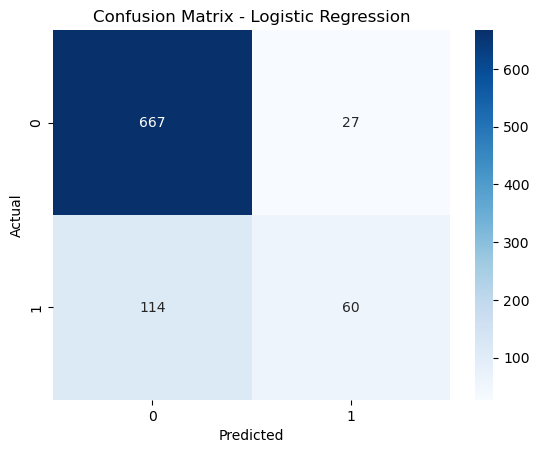

In [15]:
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [16]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8341013824884793
Precision: 0.6415094339622641
Recall: 0.39080459770114945
F1 Score: 0.4857142857142857

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       694
           1       0.64      0.39      0.49       174

    accuracy                           0.83       868
   macro avg       0.75      0.67      0.69       868
weighted avg       0.82      0.83      0.82       868



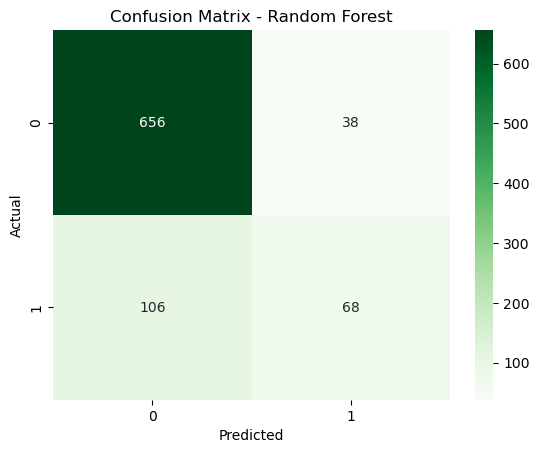

In [18]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

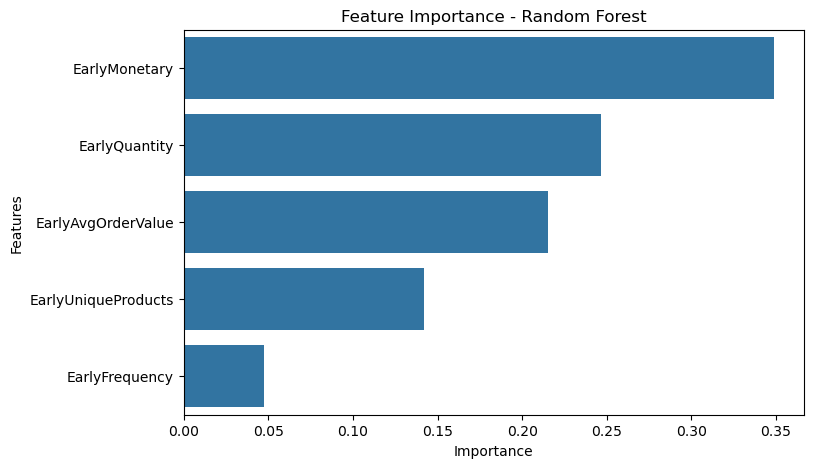

EarlyMonetary          0.348861
EarlyQuantity          0.246631
EarlyAvgOrderValue     0.215267
EarlyUniqueProducts    0.141833
EarlyFrequency         0.047409
dtype: float64

In [19]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

importances

## ROC Curve and AUC Analysis

To further evaluate model performance, ROC curves and AUC scores are used.

ROC-AUC provides a more comprehensive evaluation metric for imbalanced classification problems by measuring the trade-off between true positive rate and false positive rate across different thresholds.


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

In [21]:
# Logistic Regression probabilities
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# ROC curve
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_prob_log)

# AUC score
auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression AUC:", auc_log)

Logistic Regression AUC: 0.7982626122097453


In [22]:
# Random Forest probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ROC curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

# AUC score
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest AUC:", auc_rf)

Random Forest AUC: 0.7665457617012819


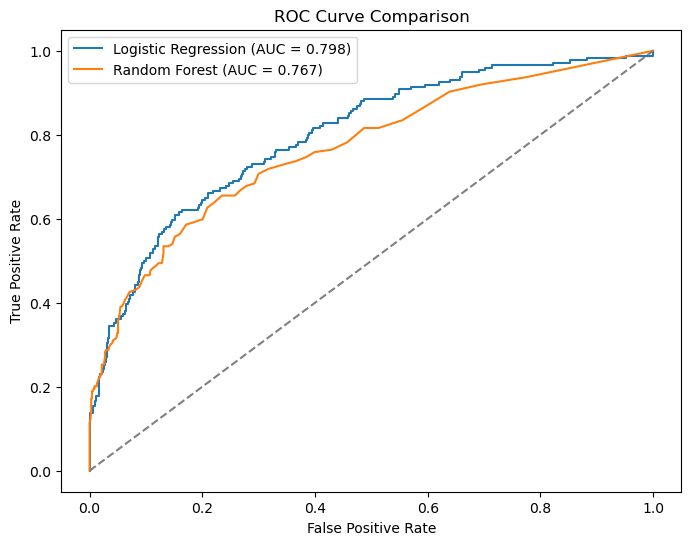

In [23]:
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## Cross Validation

To evaluate model stability and generalization performance, cross-validation was applied.

Cross-validation reduces the risk of overfitting by repeatedly splitting the dataset into different training and validation sets.

In [24]:
from sklearn.model_selection import cross_val_score

In [25]:
# Cross-validation for Logistic Regression

cv_scores_log = cross_val_score(
    log_model,
    X,
    y,
    cv=5,
    scoring='f1'
)

print("Logistic Regression CV Scores:", cv_scores_log)
print("Mean CV Score:", cv_scores_log.mean())

Logistic Regression CV Scores: [0.59027778 0.44081633 0.46692607 0.38709677 0.47244094]
Mean CV Score: 0.47151157868454774


In [26]:
# Cross-validation for Random Forest

cv_scores_rf = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='f1'
)

print("Random Forest CV Scores:", cv_scores_rf)
print("Mean CV Score:", cv_scores_rf.mean())

Random Forest CV Scores: [0.54654655 0.46715328 0.4751773  0.38022814 0.48727273]
Mean CV Score: 0.47127560006749497


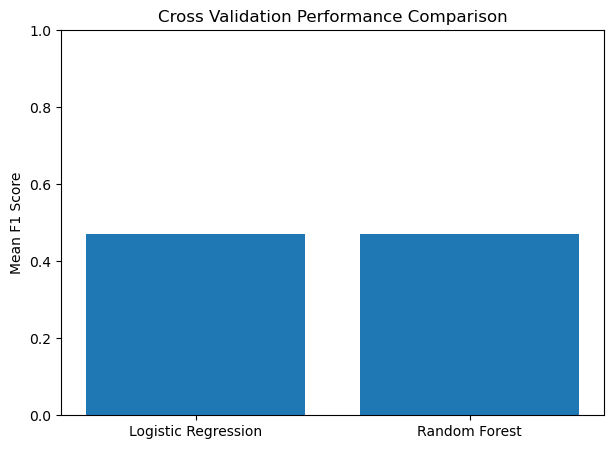

In [27]:
models = ["Logistic Regression", "Random Forest"]
scores = [cv_scores_log.mean(), cv_scores_rf.mean()]

plt.figure(figsize=(7,5))

plt.bar(models, scores)

plt.ylabel("Mean F1 Score")
plt.title("Cross Validation Performance Comparison")

plt.ylim(0,1)

plt.show()

## Hyperparameter Tuning

To further improve model performance, hyperparameter tuning was performed on the Random Forest model.

Different parameter combinations were tested to identify a better-performing configuration.

In [28]:
from sklearn.model_selection import GridSearchCV

In [29]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 Score: 0.5037443932244499


## Tuned Random Forest Evaluation

After hyperparameter tuning, the optimized Random Forest model was evaluated on the test set.

The tuned model achieved improved F1-score performance, indicating better balance between precision and recall.

In [30]:
# Tuned Random Forest model

tuned_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

tuned_rf.fit(X_train, y_train)

y_pred_tuned = tuned_rf.predict(X_test)

In [31]:
print("Tuned Random Forest Performance")
print()

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))

print()
print("Classification Report:")
print()
print(classification_report(y_test, y_pred_tuned))

Tuned Random Forest Performance

Accuracy: 0.8306451612903226
Precision: 0.6336633663366337
Recall: 0.367816091954023
F1 Score: 0.46545454545454545

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       694
           1       0.63      0.37      0.47       174

    accuracy                           0.83       868
   macro avg       0.75      0.66      0.68       868
weighted avg       0.81      0.83      0.81       868



In [32]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_tuned)
    ],
    "AUC": [
        auc_log,
        auc_rf,
        roc_auc_score(
            y_test,
            tuned_rf.predict_proba(X_test)[:,1]
        )
    ]
})

comparison_df

,Model,F1 Score,AUC
0,Logistic Regression,0.459770,0.798263
1,Random Forest,0.485714,0.766546
2,Tuned Random Forest,0.465455,0.773668


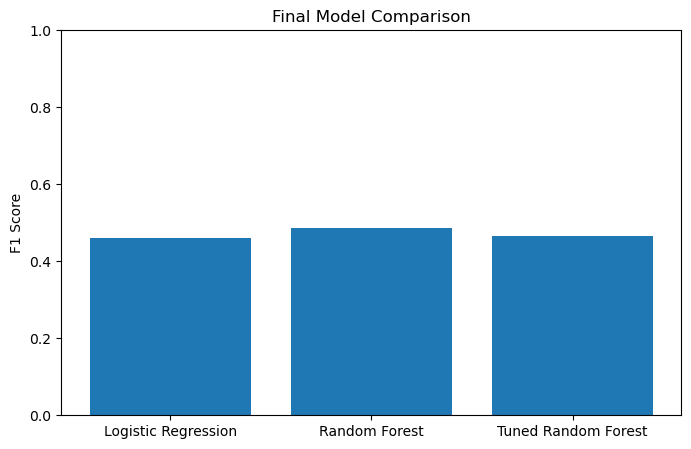

In [33]:
plt.figure(figsize=(8,5))

plt.bar(comparison_df["Model"], comparison_df["F1 Score"])

plt.ylabel("F1 Score")
plt.title("Final Model Comparison")

plt.ylim(0,1)

plt.show()

## Final Model Interpretation

The machine learning results show that early customer behavior contains useful signals for predicting high-value customers.

Logistic Regression achieved the highest ROC-AUC score, suggesting that the relationship between early spending behavior and customer value is partly linear and interpretable.

Random Forest improved recall compared to Logistic Regression, meaning it was better at identifying actual high-value customers. This is important because missing a high-value customer may be more costly than mistakenly targeting a low-value customer.

After hyperparameter tuning, the Random Forest model achieved a higher cross-validation F1-score, showing better balance between precision and recall.

Overall, EarlyMonetary, EarlyQuantity, and EarlyAvgOrderValue were the most important predictors. This suggests that the amount and intensity of early spending are more informative than frequency alone.

From a business perspective, these findings indicate that firms can identify promising customers early and design targeted retention or personalization strategies.